In [5]:
# Import required libraries
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [6]:
# Load cleaned data — NOT WoE transformed
# XGBoost works on raw features directly
X = pd.read_csv("../data/processed/X_cleaned.csv", index_col=0)
y = pd.read_csv("../data/processed/y_cleaned.csv", index_col=0).squeeze()

# Drop real_estate_loans — IV below useless threshold (0.0121)
X = X.drop(columns=["real_estate_loans"])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Default rate: {y.mean():.2%}")
print(f"\nFeatures: {X.columns.tolist()}")

X shape: (149986, 9)
y shape: (149986,)
Default rate: 6.68%

Features: ['age', 'monthly_income', 'debt_ratio', 'revolving_util', 'open_credit_lines', 'n_dependents', 'dpd_30_59', 'dpd_60_89', 'dpd_90_plus']


## XGBoost Champion Model

### Why XGBoost as champion?
The logistic regression scorecard (Gini 0.7237) is our interpretable
challenger — maintained for regulatory explainability and adverse action
notices. XGBoost is the champion because:

1. **Non-linear relationships:** Captures complex interactions natively
   without WoE pre-transformation
2. **Correlated features:** Tree models handle 0.98-correlated DPD columns
   without coefficient instability
3. **Missing values:** Handles natively via the `missing` parameter —
   no imputation required in principle
4. **Performance:** Typically outperforms logistic regression by 3–8
   Gini points on credit data

### Raw features, not WoE
WoE transformation linearises relationships for logistic regression.
XGBoost finds its own optimal split points — pre-binning via WoE
would discard information and hurt performance.

### Class imbalance handling
Default rate is 6.68% — 13.9:1 imbalance ratio.
XGBoost handles this via `scale_pos_weight = 13.9`, which tells the
model to weight each default 13.9x more than a non-default during
training.

### Evaluation metric
`eval_metric = "auc"` — consistent with the scorecard evaluation.
Primary comparison metric: Gini coefficient.

In [7]:
# Data Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,   # same seed as scorecard
    stratify=y,
)

# Class imbalance ratio for scale_pos_weight
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Training set:  {X_train.shape} | Default rate: {y_train.mean():.2%}")
print(f"Test set:      {X_test.shape}  | Default rate: {y_test.mean():.2%}")
print(f"\nImbalance ratio (scale_pos_weight): {imbalance_ratio:.2f}")

Training set:  (119988, 9) | Default rate: 6.68%
Test set:      (29998, 9)  | Default rate: 6.68%

Imbalance ratio (scale_pos_weight): 13.96


In [8]:
# Baseline XGBoost model
xgb_baseline = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# Performance
y_train_prob = xgb_baseline.predict_proba(X_train)[:, 1]
y_test_prob  = xgb_baseline.predict_proba(X_test)[:, 1]

train_auc  = roc_auc_score(y_train, y_train_prob)
test_auc   = roc_auc_score(y_test,  y_test_prob)
train_gini = 2 * train_auc - 1
test_gini  = 2 * test_auc  - 1

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)
ks_stat = (tpr - fpr).max()

print("=" * 50)
print("XGBOOST BASELINE PERFORMANCE")
print("=" * 50)
print(f"{'Metric':<25} {'Train':>10} {'Test':>10}")
print("-" * 50)
print(f"{'AUC-ROC':<25} {train_auc:>10.4f} {test_auc:>10.4f}")
print(f"{'Gini':<25} {train_gini:>10.4f} {test_gini:>10.4f}")
print("-" * 50)
print(f"{'KS Statistic (test)':<25} {ks_stat:>10.4f}")
print(f"{'Best iteration':<25} {xgb_baseline.best_iteration:>10}")
print("=" * 50)

# vs scorecard
print(f"\nGini improvement over scorecard baseline:")
print(f"  Scorecard : 0.7237")
print(f"  XGBoost   : {test_gini:.4f}")
print(f"  Delta     : +{test_gini - 0.7237:.4f}")

XGBOOST BASELINE PERFORMANCE
Metric                         Train       Test
--------------------------------------------------
AUC-ROC                       0.8742     0.8734
Gini                          0.7484     0.7468
--------------------------------------------------
KS Statistic (test)           0.5896
Best iteration                   206

Gini improvement over scorecard baseline:
  Scorecard : 0.7237
  XGBoost   : 0.7468
  Delta     : +0.0231


In [9]:
# Hyperparameter tuning with GridSearchCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [3, 4, 5],
    "learning_rate":    [0.01, 0.05, 0.1],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=imbalance_ratio,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    verbose=1,
    n_jobs=-1,
)

print("Starting grid search...")
print(f"Total combinations: {3*3*3*2*2} × 5 folds = {3*3*3*2*2*5} fits")
print("This will take 10–15 minutes...\n")

grid_search.fit(X_train, y_train)

print(f"\nBest AUC (CV):  {grid_search.best_score_:.4f}")
print(f"Best Gini (CV): {2 * grid_search.best_score_ - 1:.4f}")
print(f"\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k:<25} {v}")

Starting grid search...
Total combinations: 108 × 5 folds = 540 fits
This will take 10–15 minutes...

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best AUC (CV):  0.8625
Best Gini (CV): 0.7250

Best parameters:
  colsample_bytree          0.8
  learning_rate             0.05
  max_depth                 3
  n_estimators              300
  subsample                 0.8


In [10]:
xgb_tuned = xgb.XGBClassifier(
    **grid_search.best_params_,
    scale_pos_weight=imbalance_ratio,
    eval_metric="auc",
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1,
)

xgb_tuned.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

# Performance
y_train_prob_tuned = xgb_tuned.predict_proba(X_train)[:, 1]
y_test_prob_tuned  = xgb_tuned.predict_proba(X_test)[:, 1]

train_auc_tuned  = roc_auc_score(y_train, y_train_prob_tuned)
test_auc_tuned   = roc_auc_score(y_test,  y_test_prob_tuned)
train_gini_tuned = 2 * train_auc_tuned - 1
test_gini_tuned  = 2 * test_auc_tuned  - 1

fpr_t, tpr_t, _ = roc_curve(y_test, y_test_prob_tuned)
ks_tuned = (tpr_t - fpr_t).max()

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'Scorecard':>10} {'XGB Base':>10} {'XGB Tuned':>10}")
print("-" * 60)
print(f"{'AUC-ROC (test)':<25} {'0.8619':>10} {'0.8734':>10} {test_auc_tuned:>10.4f}")
print(f"{'Gini (test)':<25} {'0.7237':>10} {'0.7468':>10} {test_gini_tuned:>10.4f}")
print(f"{'KS (test)':<25} {'0.5712':>10} {'0.5896':>10} {ks_tuned:>10.4f}")
print("-" * 60)
print(f"{'Gini (train)':<25} {'0.7080':>10} {'0.7484':>10} {train_gini_tuned:>10.4f}")
print(f"{'Overfit gap':<25} {'-0.0157':>10} {'0.0016':>10} {train_gini_tuned - test_gini_tuned:>10.4f}")
print("=" * 60)

# Pick champion
champion_prob = y_test_prob_tuned if test_gini_tuned >= 0.7468 else y_test_prob
champion_name = "XGB Tuned" if test_gini_tuned >= 0.7468 else "XGB Baseline"
champion_gini = max(test_gini_tuned, 0.7468)
print(f"\nChampion: {champion_name} | Gini: {champion_gini:.4f}")

MODEL COMPARISON
Metric                     Scorecard   XGB Base  XGB Tuned
------------------------------------------------------------
AUC-ROC (test)                0.8619     0.8734     0.8726
Gini (test)                   0.7237     0.7468     0.7453
KS (test)                     0.5712     0.5896     0.5881
------------------------------------------------------------
Gini (train)                  0.7080     0.7484     0.7414
Overfit gap                  -0.0157     0.0016    -0.0038

Champion: XGB Baseline | Gini: 0.7468


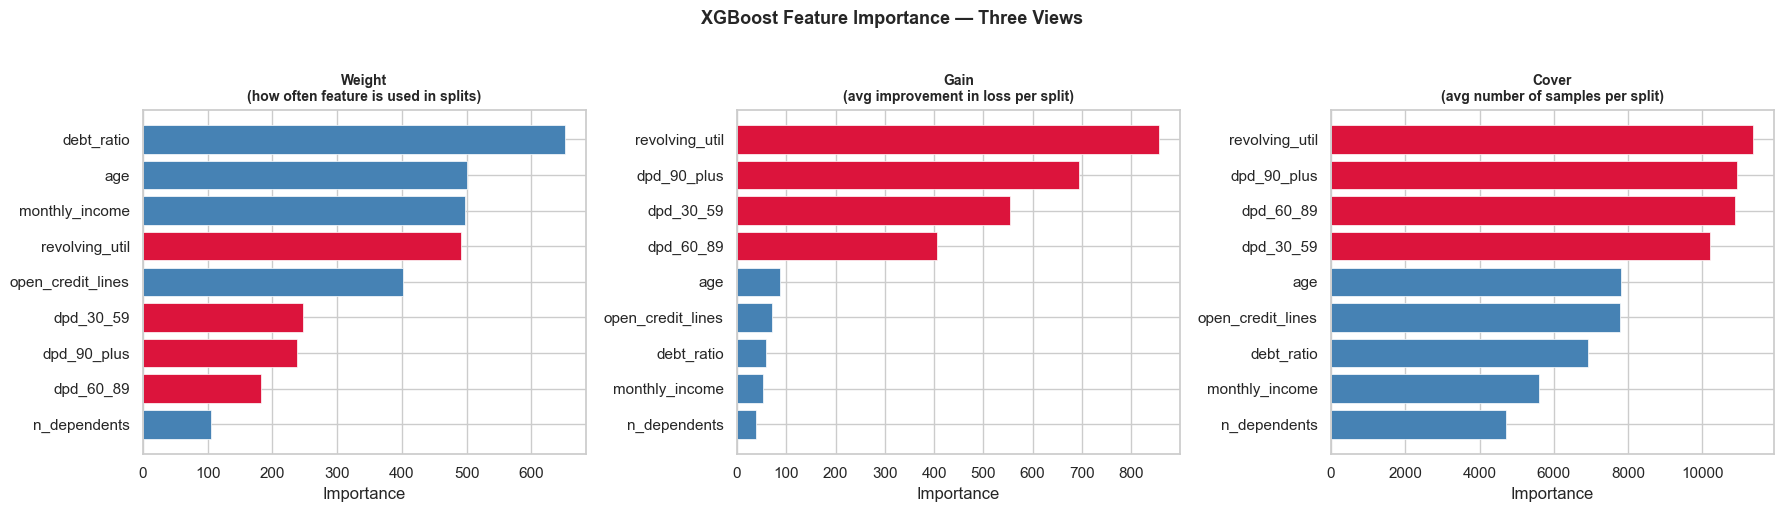

In [11]:
# Feature importance analysis on baseline model (for interpretability)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

importance_types = ["weight", "gain", "cover"]
titles = [
    "Weight\n(how often feature is used in splits)",
    "Gain\n(avg improvement in loss per split)",
    "Cover\n(avg number of samples per split)",
]

for i, (imp_type, title) in enumerate(zip(importance_types, titles)):
    importance = xgb_baseline.get_booster().get_score(importance_type=imp_type)
    imp_df = (
        pd.DataFrame(importance.items(), columns=["feature", "importance"])
        .sort_values("importance", ascending=True)
    )

    colors = ["crimson" if f in ["dpd_90_plus", "dpd_30_59", "dpd_60_89", "revolving_util"]
              else "steelblue" for f in imp_df["feature"]]

    axes[i].barh(imp_df["feature"], imp_df["importance"],
                 color=colors, edgecolor="white", linewidth=0.5)
    axes[i].set_title(title, fontweight="bold", fontsize=10)
    axes[i].set_xlabel("Importance")

plt.suptitle("XGBoost Feature Importance — Three Views",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

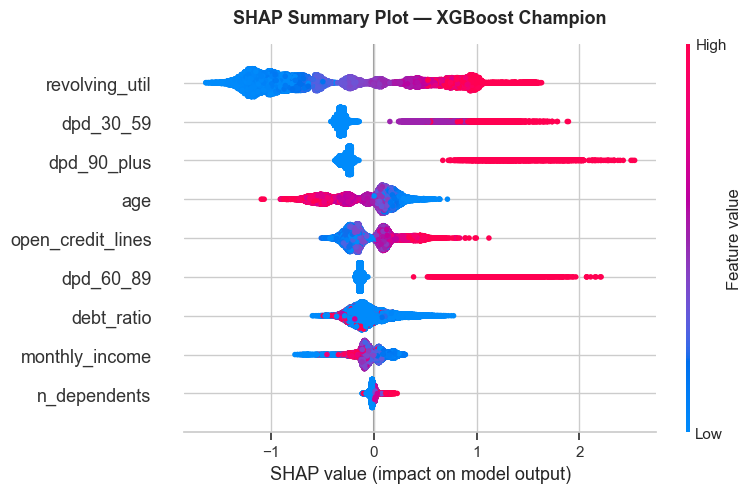

In [12]:
# SHAP values for global interpretability (direction and magnitude of feature effects)
import shap

explainer   = shap.TreeExplainer(xgb_baseline)
shap_values = explainer.shap_values(X_test)

# ── Summary plot ──────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Summary Plot — XGBoost Champion", 
          fontweight="bold", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

2026-05-23 18:04:00,186 | INFO | ==================================================
2026-05-23 18:04:00,187 | INFO | Starting cleaning pipeline
2026-05-23 18:04:00,187 | INFO | ==================================================
2026-05-23 18:04:00,306 | INFO | Loaded 150,000 rows | 11 columns | from ../data/raw/cs-training.csv
2026-05-23 18:04:00,323 | INFO | remove_bad_age: removed 14 records | 149,986 remaining
2026-05-23 18:04:00,327 | INFO | cap_revolving_util: capped 254 records at 5.0
2026-05-23 18:04:00,328 | INFO | cap_dpd_sentinels: dpd_30_59 → capped 273 records
2026-05-23 18:04:00,329 | INFO | cap_dpd_sentinels: dpd_60_89 → capped 270 records
2026-05-23 18:04:00,330 | INFO | cap_dpd_sentinels: dpd_90_plus → capped 285 records
2026-05-23 18:04:00,330 | INFO | cap_dpd_sentinels: total capped across all DPD columns: 828
2026-05-23 18:04:00,357 | INFO | impute_monthly_income: 29,724 missing → 0 remaining
2026-05-23 18:04:00,358 | INFO | impute_n_dependents: filled 3,921 nulls wi

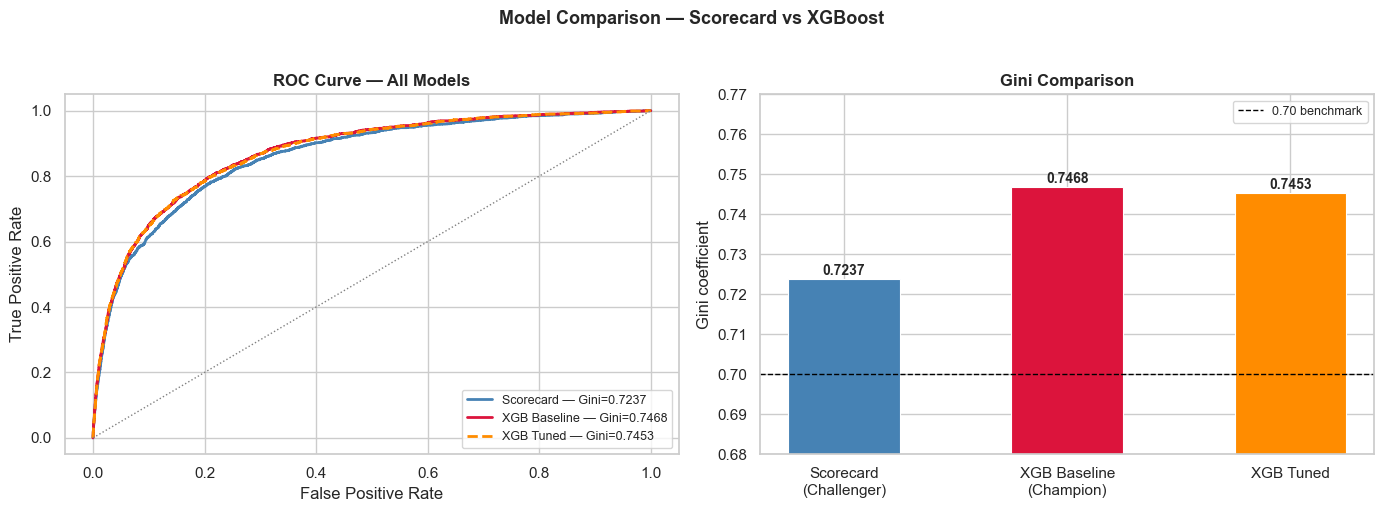

In [14]:
# ROC curve comparison (all three models)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Refit scorecard cleanly ──
from src.data.cleaning import run_cleaning_pipeline
from src.features.binning import WoEBinner
from sklearn.linear_model import LogisticRegression

# Clean data
X_clean, y_clean, _, _ = run_cleaning_pipeline("../data/raw/cs-training.csv")

# WoE transform
binner = WoEBinner()
X_woe  = binner.fit_transform(X_clean, y_clean)

# Same split — same random_state guarantees identical test set
X_train_woe, X_test_woe, y_train_sc, y_test_sc = train_test_split(
    X_woe, y_clean,
    test_size=0.20,
    random_state=42,
    stratify=y_clean,
)

lr = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs", random_state=42)
lr.fit(X_train_woe, y_train_sc)
sc_test_prob = lr.predict_proba(X_test_woe)[:, 1]

# ── ROC curves ──
fpr_sc, tpr_sc, _ = roc_curve(y_test_sc,  sc_test_prob)
fpr_xb, tpr_xb, _ = roc_curve(y_test,     y_test_prob)
fpr_xt, tpr_xt, _ = roc_curve(y_test,     y_test_prob_tuned)

auc_sc = roc_auc_score(y_test_sc, sc_test_prob)
auc_xb = roc_auc_score(y_test,    y_test_prob)
auc_xt = roc_auc_score(y_test,    y_test_prob_tuned)

gini_sc = 2 * auc_sc - 1
gini_xb = 2 * auc_xb - 1
gini_xt = 2 * auc_xt - 1

# ROC plot
axes[0].plot(fpr_sc, tpr_sc, color="steelblue", linewidth=2,
             label=f"Scorecard — Gini={gini_sc:.4f}")
axes[0].plot(fpr_xb, tpr_xb, color="crimson", linewidth=2,
             label=f"XGB Baseline — Gini={gini_xb:.4f}")
axes[0].plot(fpr_xt, tpr_xt, color="darkorange", linewidth=2, linestyle="--",
             label=f"XGB Tuned — Gini={gini_xt:.4f}")
axes[0].plot([0, 1], [0, 1], color="grey", linestyle=":", linewidth=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — All Models", fontweight="bold")
axes[0].legend(fontsize=9)

# Gini bar chart
models = ["Scorecard\n(Challenger)", "XGB Baseline\n(Champion)", "XGB Tuned"]
ginis  = [gini_sc, gini_xb, gini_xt]
colors = ["steelblue", "crimson", "darkorange"]
bars   = axes[1].bar(models, ginis, color=colors,
                     edgecolor="white", linewidth=0.8, width=0.5)
axes[1].set_ylim(0.68, 0.77)
axes[1].set_ylabel("Gini coefficient")
axes[1].set_title("Gini Comparison", fontweight="bold")
axes[1].axhline(0.70, color="black", linestyle="--",
                linewidth=1, label="0.70 benchmark")
axes[1].legend(fontsize=9)
for bar, gini in zip(bars, ginis):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{gini:.4f}", ha="center",
        fontweight="bold", fontsize=10,
    )

plt.suptitle("Model Comparison — Scorecard vs XGBoost",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Save champion and other models
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save champion
joblib.dump(xgb_baseline, "../models/champion_xgb.joblib")

# Save challenger
joblib.dump(lr, "../models/challenger_scorecard.joblib")

# Save binner — needed to transform new data for scorecard
binner.save("../models/woe_binner.json")

print("Saved:")
print("  ../models/champion_xgb.joblib")
print("  ../models/challenger_scorecard.joblib")
print("  ../models/woe_binner.json")

# Verify by reloading
champion   = joblib.load("../models/champion_xgb.joblib")
challenger = joblib.load("../models/challenger_scorecard.joblib")

verify_prob = champion.predict_proba(X_test)[:, 1]
verify_gini = 2 * roc_auc_score(y_test, verify_prob) - 1
print(f"\nVerification — Champion Gini after reload: {verify_gini:.4f}")

2026-05-23 18:08:07,095 | INFO | WoEBinner saved → ../models/woe_binner.json


Saved:
  ../models/champion_xgb.joblib
  ../models/challenger_scorecard.joblib
  ../models/woe_binner.json

Verification — Champion Gini after reload: 0.7468
